# MetroMart - Supermarket Sales Performance Analysis
**QUESTION.** The store manager wants answers to four questions:

Which branch generates the most revenue?

Which product category deserves promotional attention?

When are the busiest selling hours?

Does the membership program appear to increase average order value?

**ROLE.** Analyst reporting to the Head of the Store Operations

**STACK.** pandas-numpy-seaborn-matplotlib

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

In [6]:
sales_raw = pd.read_csv("../data/MetroMart_practice_raw.csv")

In [7]:
sales_raw.head()

,Order ID,Branch,City,Customer Type,Gender,Product,Unit Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,ORD-10001,East,Salt Lake,Member,Female,Computer Accessories,125.30,4,25.06,526.25,21-02-2026,18:25,Credit Card,9.3
1,ORD-10002,East,Salt Lake,Member,Female,Smartphones,491.58,2,49.16,1032.31,15-01-2026,14:15,Cash,9.1
2,ORD-10003,Central,Kolkata,Member,Female,Computer Accessories,118.49,1,5.92,124.41,13-03-2026,13:25,UPI,7.5
3,ORD-10004,North,Kolkata,Member,Female,Home Appliances,270.01,3,40.50,850.55,02-03-2026,18:05,Credit Card,8.8
4,ORD-10005,Central,Kolkata,Member,Male,Computer Accessories,101.10,2,10.11,212.30,21-01-2026,18:55,Credit Card,10.0


In [8]:
print ("shape: ", sales_raw.shape)

shape:  (532, 14)


In [9]:
print ("Column wise data types: ")
sales_raw.dtypes

Column wise data types: 


Order ID             str
Branch               str
City                 str
Customer Type        str
Gender               str
Product              str
Unit Price       float64
Quantity           int64
Tax              float64
Total            float64
Date                 str
Time                 str
Payment              str
Rating           float64
dtype: object

In [10]:
print ("missing values in each column: ")
sales_raw.isna().sum()

missing values in each column: 


Order ID         0
Branch           0
City             0
Customer Type    7
Gender           0
Product          0
Unit Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           8
dtype: int64

In [11]:
print("Duplicate rows: ")
print (sales_raw.duplicated().sum())

Duplicate rows: 
8


In [12]:
print("We find that the column 'Customer type' and 'Rating' contain missing values. \nThere are 8 identical rows. \n'Date' and 'Time' are given in string format.")

We find that the column 'Customer type' and 'Rating' contain missing values. 
There are 8 identical rows. 
'Date' and 'Time' are given in string format.


In [13]:
print ("Numeric Summary: ")
print (sales_raw.describe().round(2))

Numeric Summary: 
       Unit Price  Quantity     Tax    Total  Rating
count      532.00    532.00  532.00   532.00  524.00
mean       279.74      2.17   30.73   645.27    7.62
std        195.22      1.23   31.12   653.42    1.16
min         70.46     -2.00  -48.56 -1019.72    4.00
25%        121.68      1.00   11.32   237.64    6.88
50%        214.33      2.00   20.40   428.40    7.60
75%        401.74      3.00   39.07   820.39    8.50
max        794.59      5.00  193.63  4066.32   10.00


In [14]:
print ("We can also see that the 'Quantity' and 'Total' columns have negative values which shouldn't occur in standard sales data.")

We can also see that the 'Quantity' and 'Total' columns have negative values which shouldn't occur in standard sales data.


In [15]:
sales=sales_raw.copy()

In [16]:
print("Row count before cleaning: ",len(sales))

Row count before cleaning:  532


In [17]:
before= len(sales)
sales=sales.drop_duplicates()
after=len(sales)
print(f"Dropped {before-after} duplicated rows")

Dropped 8 duplicated rows


In [18]:
print("Row count now: ", len(sales))

Row count now:  524


In [19]:
sales.head()

,Order ID,Branch,City,Customer Type,Gender,Product,Unit Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,ORD-10001,East,Salt Lake,Member,Female,Computer Accessories,125.30,4,25.06,526.25,21-02-2026,18:25,Credit Card,9.3
1,ORD-10002,East,Salt Lake,Member,Female,Smartphones,491.58,2,49.16,1032.31,15-01-2026,14:15,Cash,9.1
2,ORD-10003,Central,Kolkata,Member,Female,Computer Accessories,118.49,1,5.92,124.41,13-03-2026,13:25,UPI,7.5
3,ORD-10004,North,Kolkata,Member,Female,Home Appliances,270.01,3,40.50,850.55,02-03-2026,18:05,Credit Card,8.8
4,ORD-10005,Central,Kolkata,Member,Male,Computer Accessories,101.10,2,10.11,212.30,21-01-2026,18:55,Credit Card,10.0


In [20]:
sales["City"]=sales["City"].astype(str).str.strip().str.title()

In [21]:
sales["Payment"]=sales["Payment"].astype(str).str.strip().str.title()

In [22]:
print("Unique cities: ", sales["City"].unique())

Unique cities:  <StringArray>
['Salt Lake', 'Kolkata', 'Howrah']
Length: 3, dtype: str


In [23]:
print("Unique payment methods: ", sales["Payment"].unique())

Unique payment methods:  <StringArray>
['Credit Card', 'Cash', 'Upi']
Length: 3, dtype: str


In [24]:
print("Negative quantity rows: ", (sales["Quantity"]<0).sum())

Negative quantity rows:  4


In [25]:
sales=sales[sales["Quantity"]>0].copy()

In [26]:
print("Rows after dropping return/refunds: ", len(sales))

Rows after dropping return/refunds:  520


In [27]:
print(f"Customer type missing: {sales["Customer Type"].isna().sum()}")

Customer type missing: 7


In [28]:
sales["Customer Type"]=sales["Customer Type"].fillna("Unknown")

In [29]:
print("Missing ratings: ",sales["Rating"].isna().sum())

Missing ratings:  8


In [30]:
median_rating = sales["Rating"].median()

In [31]:
sales["Rating"]=sales["Rating"].fillna(median_rating)

In [32]:
print("Missing values remaining: \n")
print(sales.isna().sum())

Missing values remaining: 

Order ID         0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Unit Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64


In [33]:
sales.shape

(520, 14)

In [34]:
sales.head()

,Order ID,Branch,City,Customer Type,Gender,Product,Unit Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,ORD-10001,East,Salt Lake,Member,Female,Computer Accessories,125.30,4,25.06,526.25,21-02-2026,18:25,Credit Card,9.3
1,ORD-10002,East,Salt Lake,Member,Female,Smartphones,491.58,2,49.16,1032.31,15-01-2026,14:15,Cash,9.1
2,ORD-10003,Central,Kolkata,Member,Female,Computer Accessories,118.49,1,5.92,124.41,13-03-2026,13:25,Upi,7.5
3,ORD-10004,North,Kolkata,Member,Female,Home Appliances,270.01,3,40.50,850.55,02-03-2026,18:05,Credit Card,8.8
4,ORD-10005,Central,Kolkata,Member,Male,Computer Accessories,101.10,2,10.11,212.30,21-01-2026,18:55,Credit Card,10.0


In [35]:
sales["date"]=pd.to_datetime(sales["Date"], format="%d-%m-%Y")

In [36]:
sales["Day"]=sales["date"].dt.day_name()

In [37]:
sales["Month"]=sales["date"].dt.month_name()

In [38]:
sales["hour"]=pd.to_datetime(sales["Time"], format="%H:%M").dt.hour

In [39]:
sales.head()

,Order ID,Branch,City,Customer Type,Gender,Product,Unit Price,Quantity,Tax,Total,Date,Time,Payment,Rating,date,Day,Month,hour
0,ORD-10001,East,Salt Lake,Member,Female,Computer Accessories,125.30,4,25.06,526.25,21-02-2026,18:25,Credit Card,9.3,2026-02-21,Saturday,February,18
1,ORD-10002,East,Salt Lake,Member,Female,Smartphones,491.58,2,49.16,1032.31,15-01-2026,14:15,Cash,9.1,2026-01-15,Thursday,January,14
2,ORD-10003,Central,Kolkata,Member,Female,Computer Accessories,118.49,1,5.92,124.41,13-03-2026,13:25,Upi,7.5,2026-03-13,Friday,March,13
3,ORD-10004,North,Kolkata,Member,Female,Home Appliances,270.01,3,40.50,850.55,02-03-2026,18:05,Credit Card,8.8,2026-03-02,Monday,March,18
4,ORD-10005,Central,Kolkata,Member,Male,Computer Accessories,101.10,2,10.11,212.30,21-01-2026,18:55,Credit Card,10.0,2026-01-21,Wednesday,January,18


In [40]:
print("Gross revenue(incl. taxes): ",sales["Total"].sum())
print("Quantities sold: ", sales["Total"].sum())
print("Number of unique orders: ", sales["Order ID"].nunique())
print("AOV: ",sales["Total"].mean())

Gross revenue(incl. taxes):  340870.41
Quantities sold:  340870.41
Number of unique orders:  520
AOV:  655.5200192307692


In [63]:
gross_revenue = sales["Total"].sum()
unique_orders = sales["Order ID"].nunique()
quantities_sold = sales["Quantity"].sum()
aov = sales["Total"].mean()

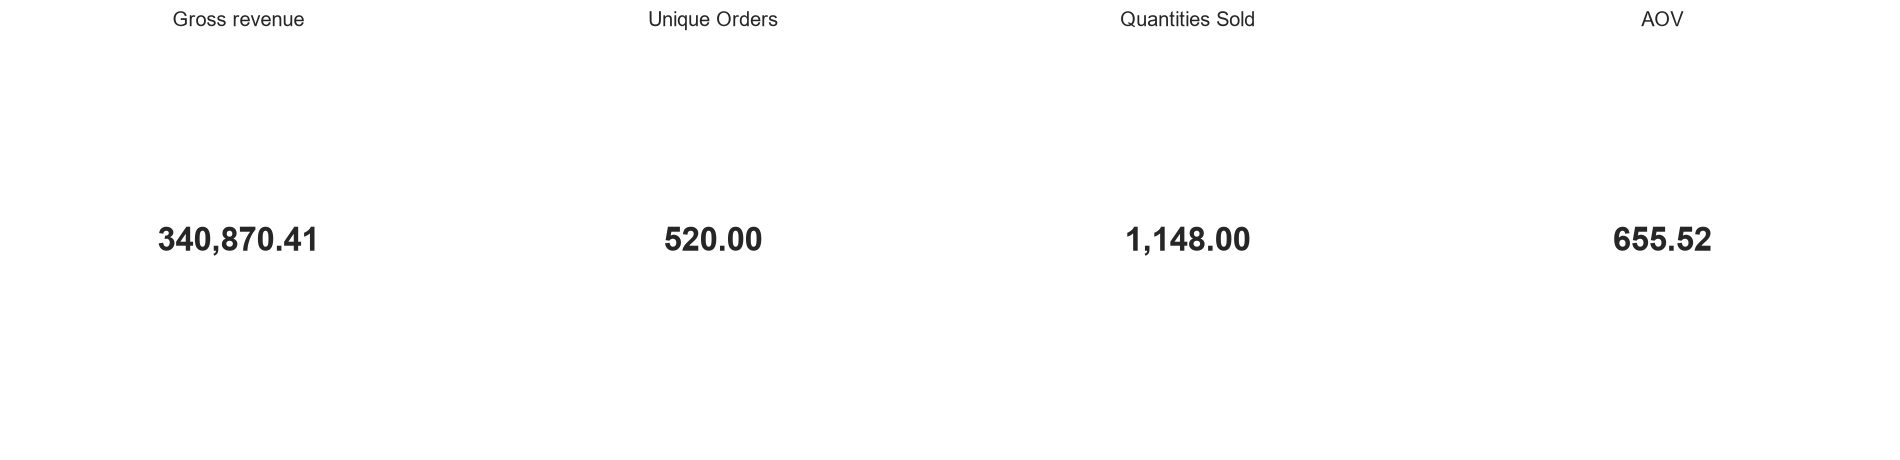

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kpis = [
    ("Gross revenue", gross_revenue),
    ("Unique Orders", unique_orders),
    ("Quantities Sold", quantities_sold),
    ("AOV", aov)
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(0.5, 0.5, f"{value:,.2f}",
            ha="center", va="center", fontsize=20, fontweight="bold")
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
date_lower_limit=sales["date"].min().date()

In [42]:
date_upper_limit=sales["date"].max().date()

In [43]:
print(f"The range for dates is {date_lower_limit} to {date_upper_limit}")

The range for dates is 2026-01-01 to 2026-03-31


In [44]:
product=(
    sales.groupby("Product" ,as_index=False).agg(
        Revenue=("Total" , "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Quantity","sum"),
        Avg_rating=("Rating", "mean"),
        AOV=("Total","mean")
    ).sort_values("Revenue", ascending=False)
)

In [45]:
product["Revenue_share_%"]=((product["Revenue"]/product["Revenue"].sum())*100).round(2)
product["Avg_rating"]=product["Avg_rating"].round(2)
product["AOV"]=product["AOV"].round(2)

In [46]:
product

,Product,Revenue,Orders,Units,Avg_rating,AOV,Revenue_share_%
3,Laptops,116328.72,71,164,7.70,1638.43,34.13
4,Smartphones,95695.42,99,219,7.65,966.62,28.07
2,Home Appliances,58706.10,109,235,7.56,538.59,17.22
5,Wearables,32731.26,76,174,7.74,430.67,9.60
1,Computer Accessories,20988.75,76,169,7.45,276.17,6.16
0,Audio Accessories,16420.16,89,187,7.64,184.50,4.82


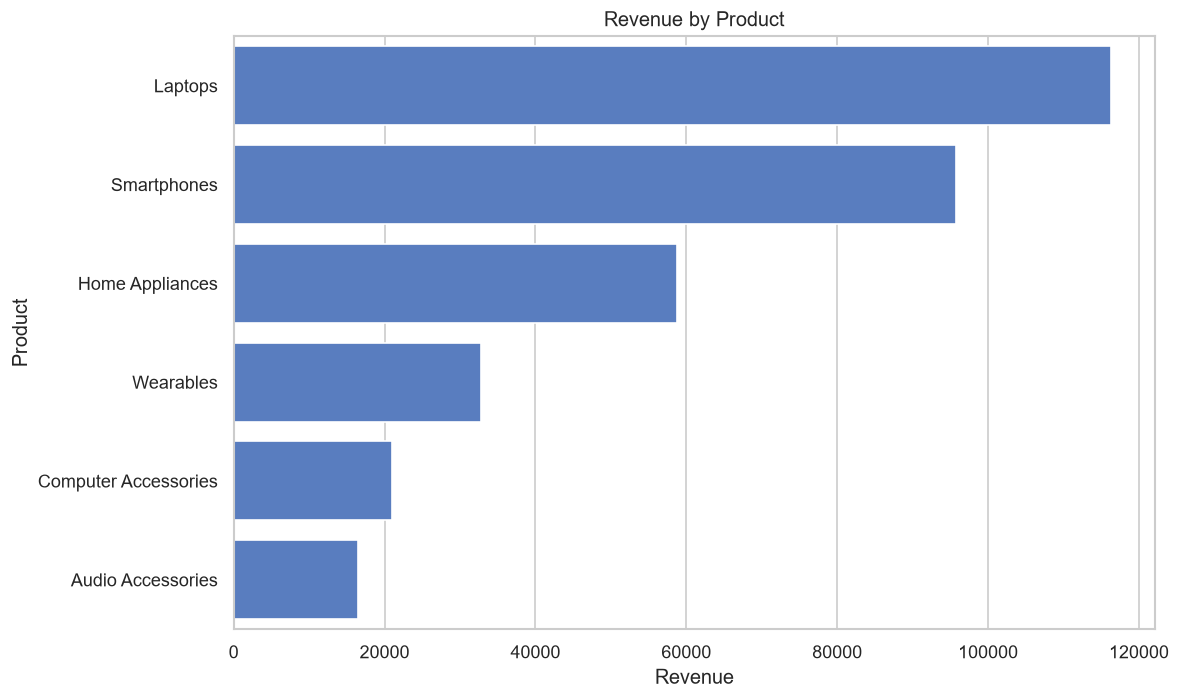

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product,
    x="Revenue",
    y="Product",
    order=product.sort_values("Revenue", ascending=False)["Product"]
)

plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

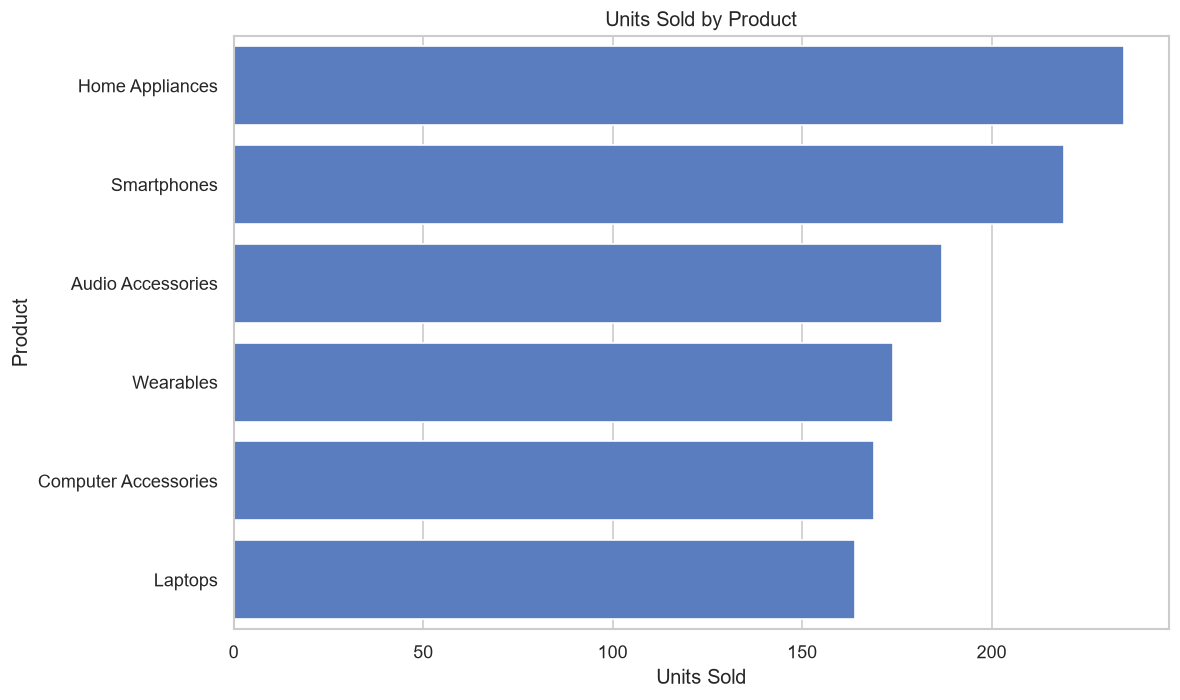

In [67]:
product_units = product.sort_values("Units", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_units,
    x="Units",
    y="Product"
)

plt.title("Units Sold by Product")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

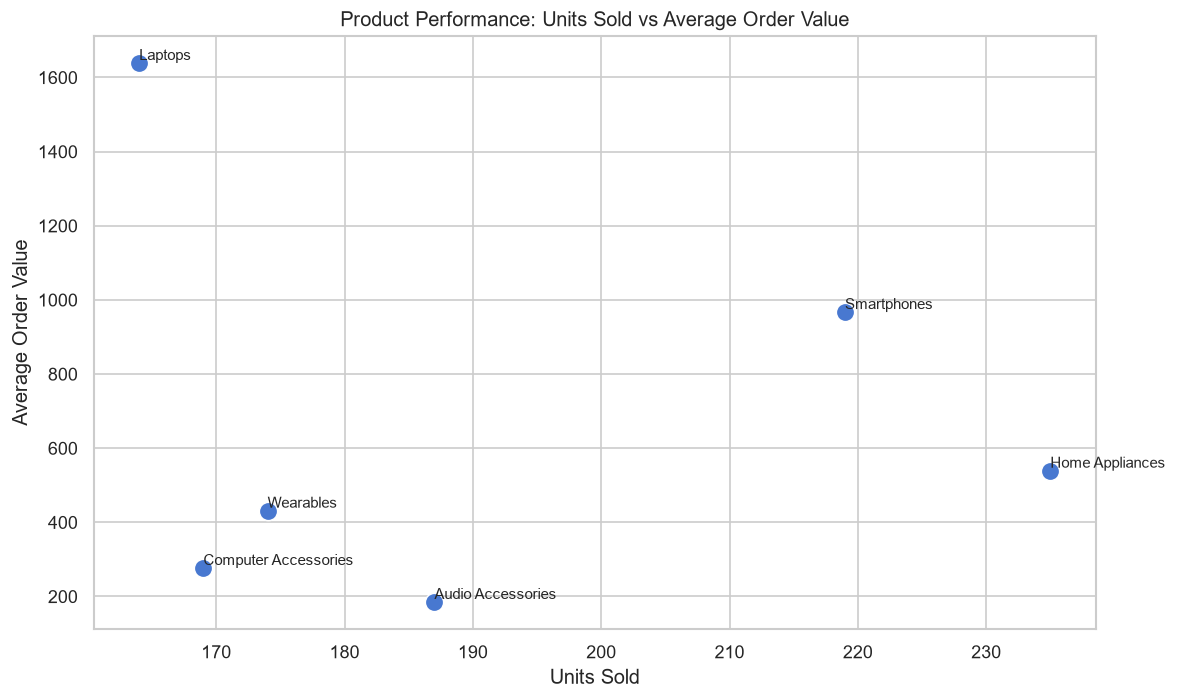

In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product,
    x="Units",
    y="AOV",
    s=120
)

for _, row in product.iterrows():
    plt.text(
        row["Units"],
        row["AOV"],
        row["Product"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("Product Performance: Units Sold vs Average Order Value")
plt.xlabel("Units Sold")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

Laptops earn the highest revenue and Home Appliances have the highest order.

In [47]:
branch=(
    sales.groupby("Branch" , as_index=False).agg(
        Revenue=("Total" , "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Quantity", "sum"),
        Avg_rating=("Rating", "mean"),
        AOV=("Total","mean")
    ).sort_values("Revenue", ascending=False)
)

In [48]:
branch["Revenue_share_%"]=((branch["Revenue"]/branch["Revenue"].sum())*100).round(2)
branch["Avg_rating"]=branch["Avg_rating"].round(2)
branch["AOV"]=branch["AOV"].round(2)

In [49]:
branch

,Branch,Revenue,Orders,Units,Avg_rating,AOV,Revenue_share_%
2,North,100144.57,157,335,7.52,637.86,29.38
1,East,81337.62,122,292,7.73,666.70,23.86
3,South,80688.59,124,259,7.62,650.71,23.67
0,Central,78699.63,117,262,7.65,672.65,23.09


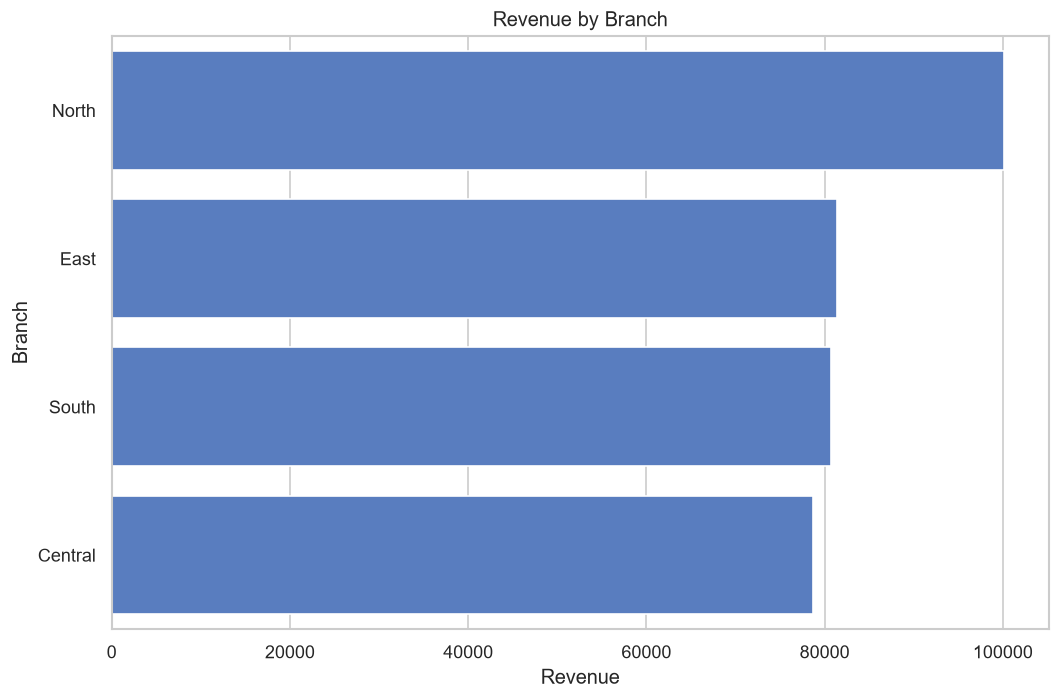

In [69]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=branch,
    x="Revenue",
    y="Branch",
    order=branch.sort_values("Revenue", ascending=False)["Branch"]
)

plt.title("Revenue by Branch")
plt.xlabel("Revenue")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

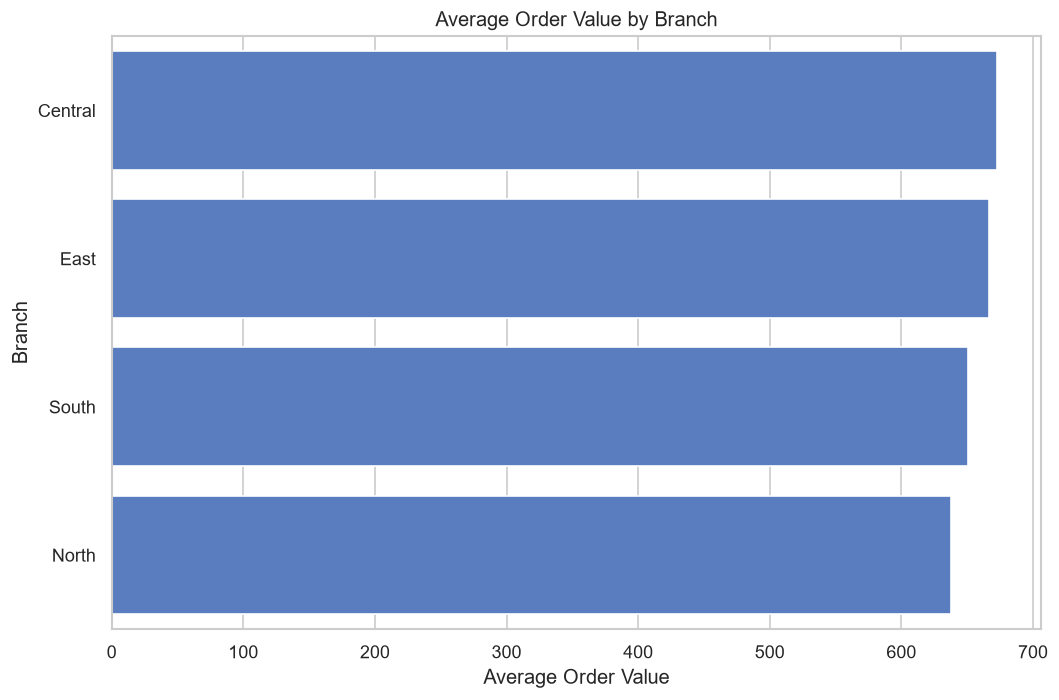

In [70]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=branch.sort_values("AOV", ascending=False),
    x="AOV",
    y="Branch"
)

plt.title("Average Order Value by Branch")
plt.xlabel("Average Order Value")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

North branch earns the highest revenue and the highest orders but their AOV is the lowest. It means the average spending of customers per order is less even though more orders are being placed.

In [50]:
customertype=(
    sales.groupby("Customer Type" , as_index=False)
    .agg(
        Revenue=("Total" , "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Quantity" , "sum"),
        Avg_rating=("Rating", "mean"),
        AOV=("Total","mean")
    ).sort_values("Revenue", ascending=False)
)

In [51]:
customertype["Revenue_share_%"]=((customertype["Revenue"]/customertype["Revenue"].sum())*100).round(2)
customertype["Avg_rating"]=customertype["Avg_rating"].round(2)
customertype["AOV"]=customertype["AOV"].round(2)

In [52]:
customertype

,Customer Type,Revenue,Orders,Units,Avg_rating,AOV,Revenue_share_%
0,Member,169092.85,274,595,7.63,617.13,49.61
1,Normal,168131.04,239,534,7.59,703.48,49.32
2,Unknown,3646.52,7,19,8.24,520.93,1.07


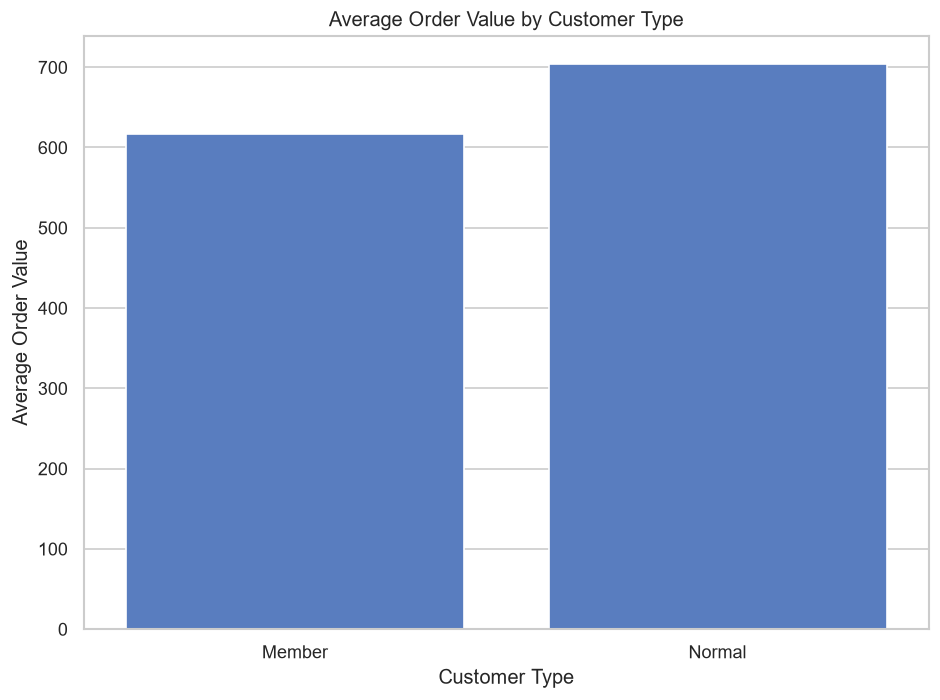

In [71]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=customertype[customertype["Customer Type"] != "Unknown"],
    x="Customer Type",
    y="AOV"
)

plt.title("Average Order Value by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

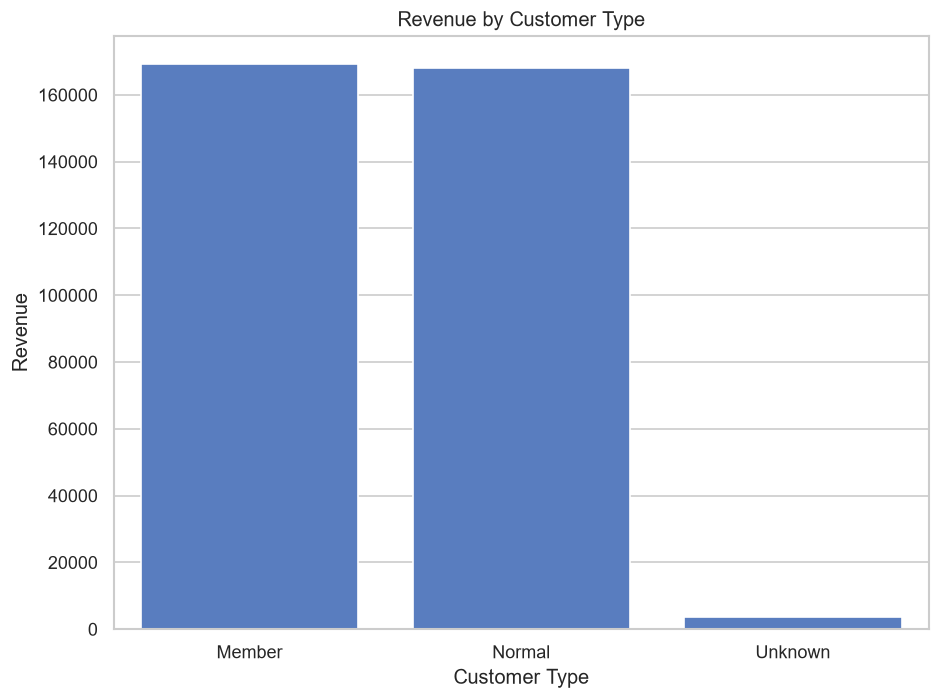

In [72]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=customertype,
    x="Customer Type",
    y="Revenue"
)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

Members earn the highest revenue but they do not have the highest AOV

In [53]:
payment=(
    sales.groupby("Payment" , as_index=False)
    .agg(
        Revenue = ("Total", "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Quantity","sum"),
        Avg_rating=("Rating", "mean"),
        AOV=("Total", "mean")
    ).sort_values("Revenue", ascending=False)
)

In [54]:
payment["Revenue_share_%"]=((payment["Revenue"]/payment["Revenue"].sum())*100).round(2)
payment["Avg_rating"]=payment["Avg_rating"].round(2)
payment["AOV"]=payment["AOV"].round(2)

In [55]:
payment

,Payment,Revenue,Orders,Units,Avg_rating,AOV,Revenue_share_%
2,Upi,144993.19,240,532,7.56,604.14,42.54
1,Credit Card,103262.51,149,312,7.71,693.04,30.29
0,Cash,92614.71,131,304,7.63,706.98,27.17


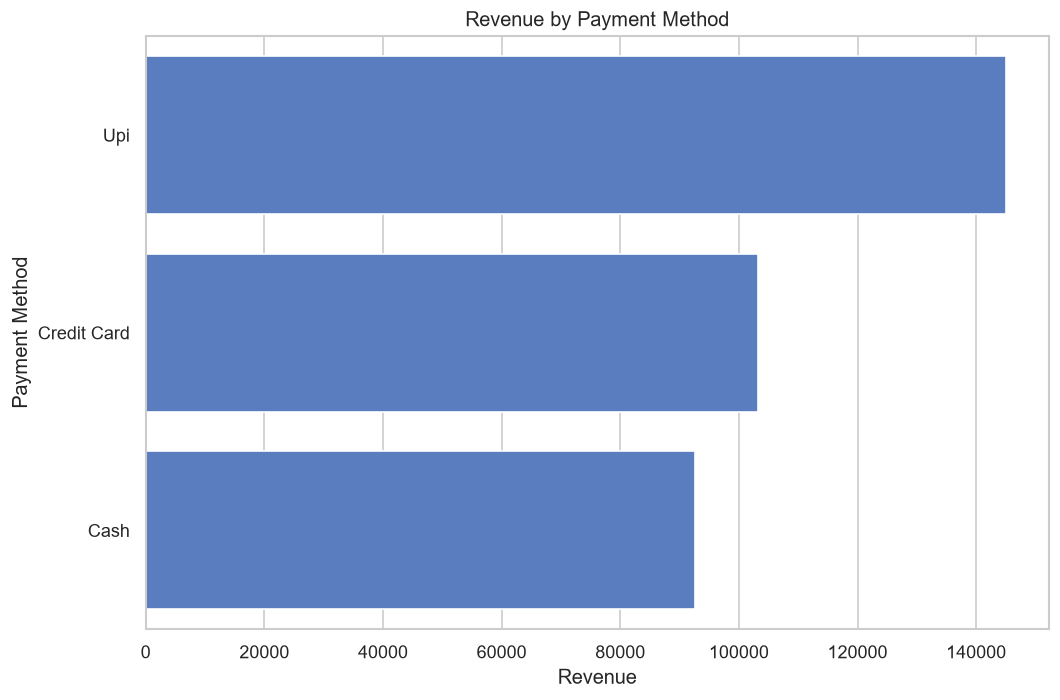

In [73]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=payment.sort_values("Revenue", ascending=False),
    x="Revenue",
    y="Payment"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Revenue")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

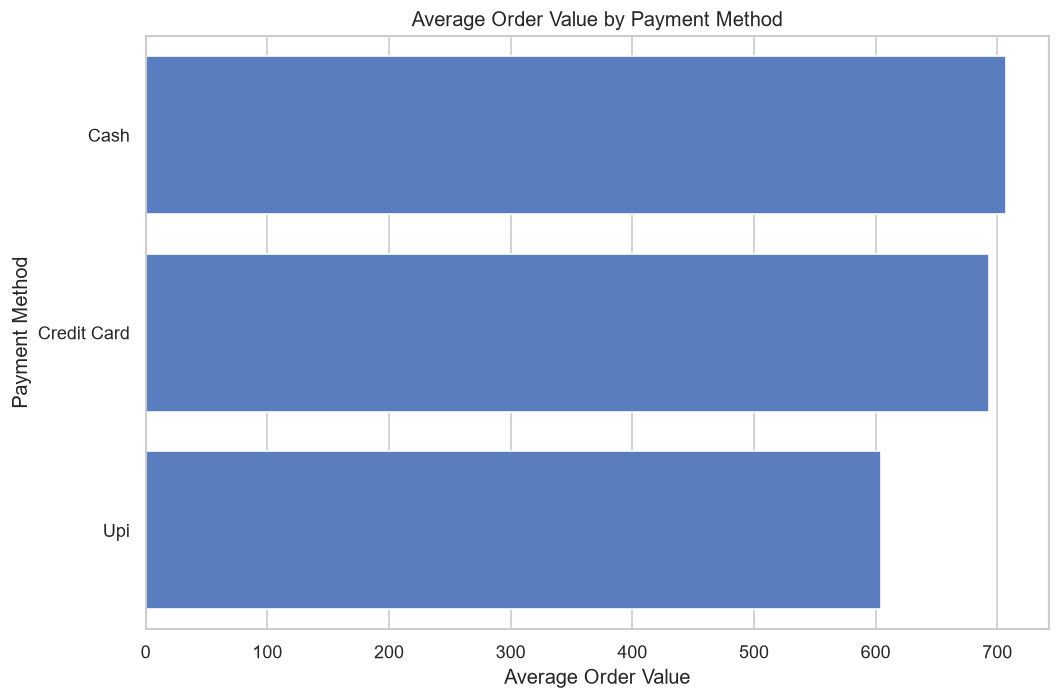

In [74]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=payment.sort_values("AOV", ascending=False),
    x="AOV",
    y="Payment"
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Average Order Value")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

In [56]:
day=(
    sales.groupby("Day" , as_index=False)
    .agg(
        Revenue=("Total", "sum")
    ).sort_values("Revenue", ascending=False)
)

In [57]:
day

,Day,Revenue
1,Monday,56366.00
0,Friday,52560.40
5,Tuesday,51249.61
4,Thursday,49694.21
2,Saturday,46139.93
3,Sunday,43390.31
6,Wednesday,41469.95


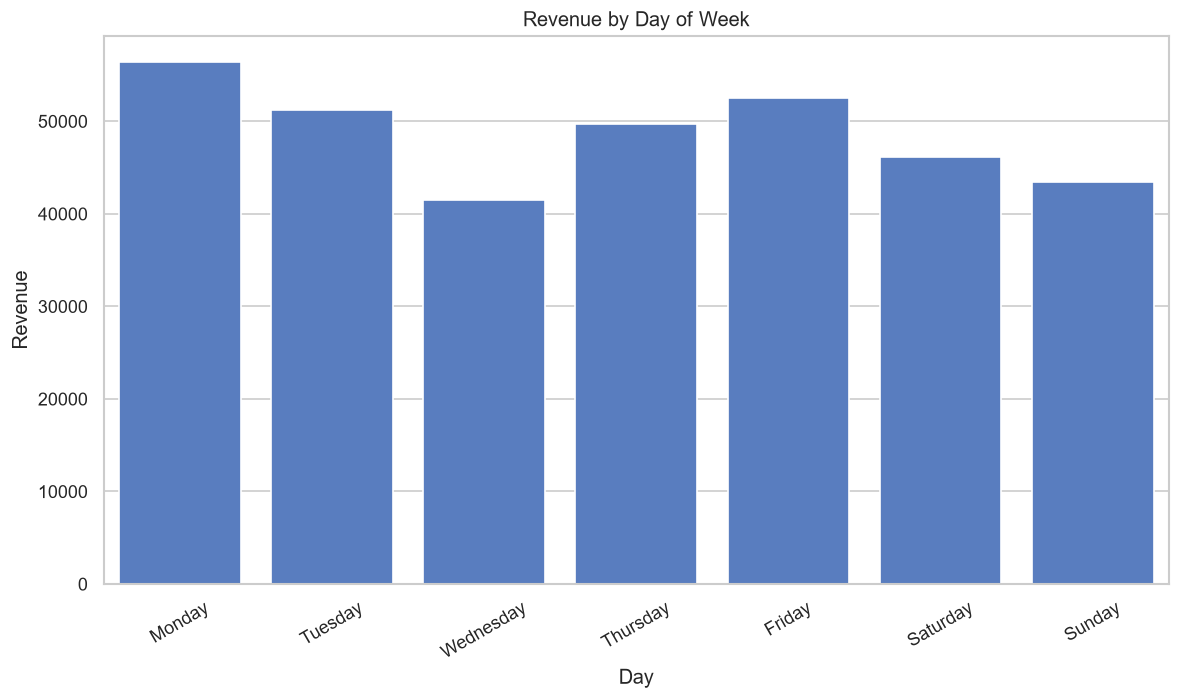

In [75]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_plot = (
    sales.groupby("Day", as_index=False)
    .agg(Revenue=("Total", "sum"))
)

day_plot["Day"] = pd.Categorical(
    day_plot["Day"],
    categories=day_order,
    ordered=True
)

day_plot = day_plot.sort_values("Day")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_plot,
    x="Day",
    y="Revenue"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Highest Revenue of the week is generated on Monday. 

In [58]:
hour=(
    sales.groupby("hour", as_index=False)
    .agg(
        Revenue=("Total", "sum")
    ).sort_values("Revenue", ascending=False)
)

In [59]:
hour

,hour,Revenue
7,17,48139.29
8,18,46756.04
6,16,36353.36
10,20,36281.05
9,19,35815.70
5,15,34845.53
4,14,27444.85
2,12,23326.90
3,13,21812.24
1,11,16467.03


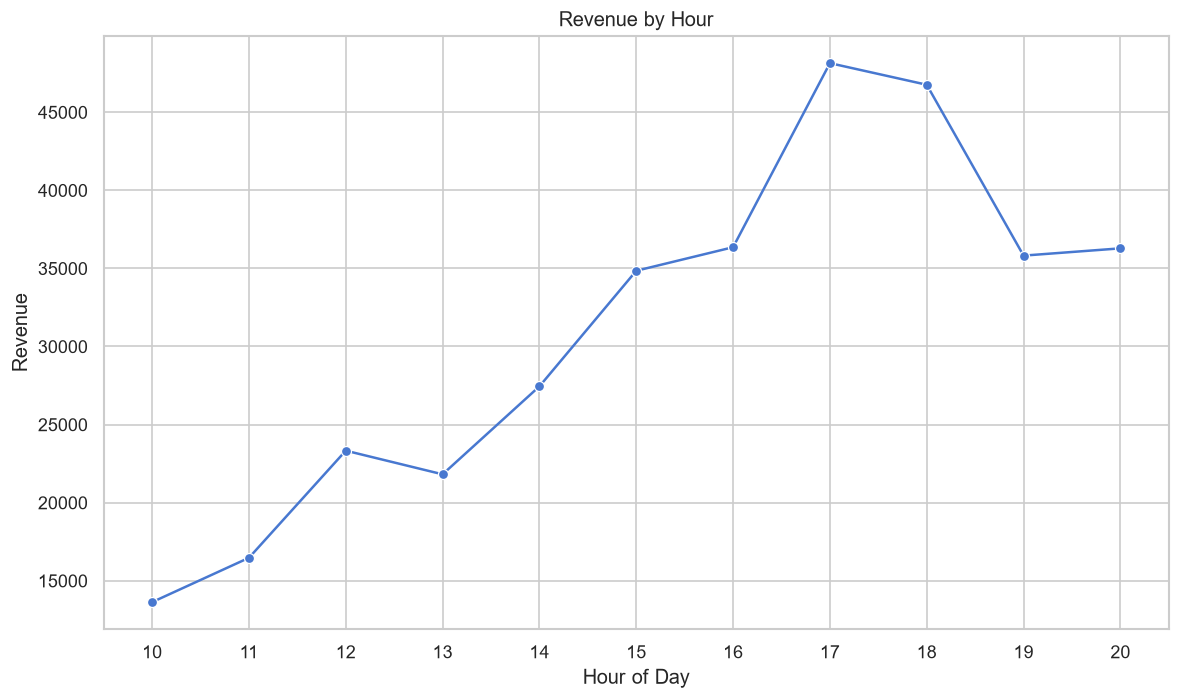

In [76]:
hour_plot = (
    sales.groupby("hour", as_index=False)
    .agg(Revenue=("Total", "sum"))
    .sort_values("hour")
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hour_plot,
    x="hour",
    y="Revenue",
    marker="o"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(hour_plot["hour"])
plt.tight_layout()
plt.show()

17:00 is the busiest hour and generates the highest revenue

In [60]:
print(sales["Rating"].corr(sales["Total"]))

-0.012771003960208296


The correlation coefficient between "Rating" and "Total" indicates an almost negligible negative linear correlation between them.

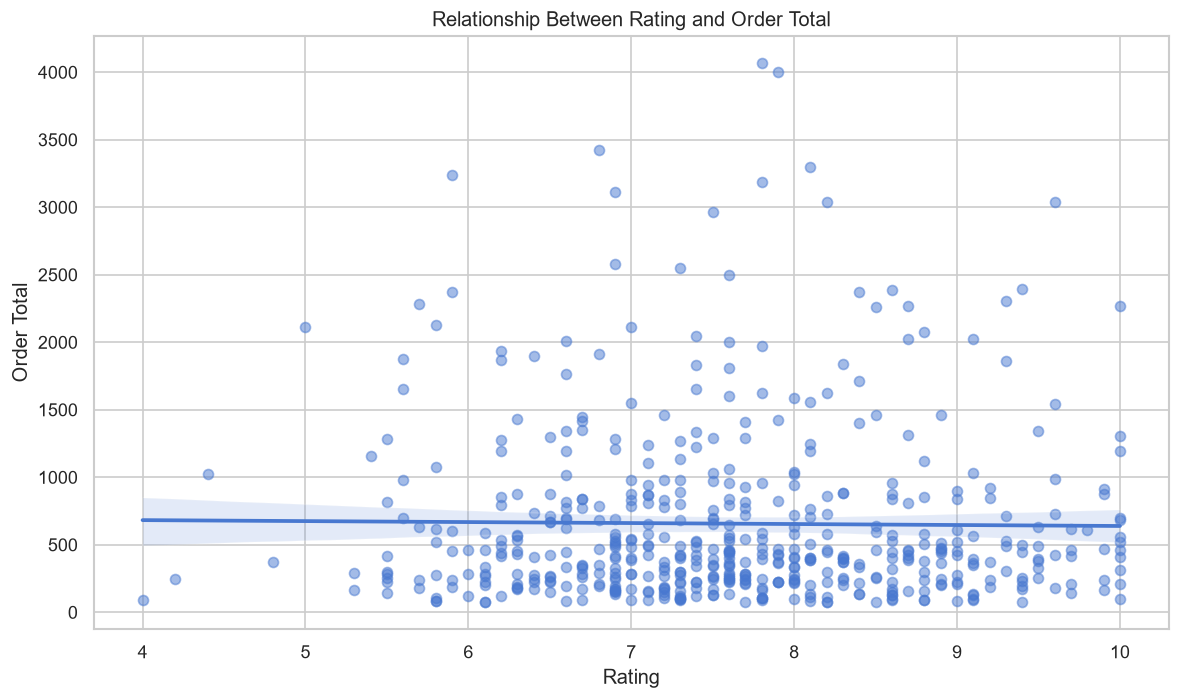

In [77]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=sales,
    x="Rating",
    y="Total",
    scatter_kws={"alpha": 0.5}
)

plt.title("Relationship Between Rating and Order Total")
plt.xlabel("Rating")
plt.ylabel("Order Total")
plt.tight_layout()
plt.show()

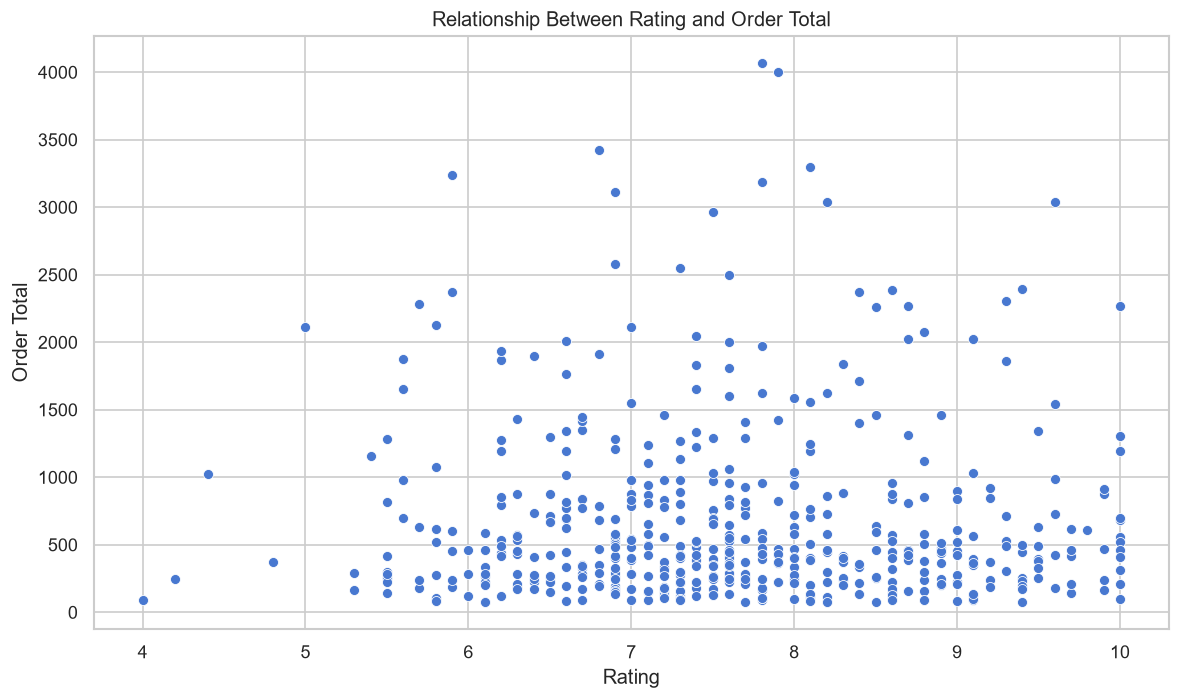

In [78]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sales,
    x="Rating",
    y="Total"
)

plt.title("Relationship Between Rating and Order Total")
plt.xlabel("Rating")
plt.ylabel("Order Total")
plt.tight_layout()
plt.show()

# Key Insights

* **Overall sales performance:** The dataset records approximately **520 unique `Order ID`**, with a total `Quantity` of **1,148 units** and gross revenue of approximately **340,870.41** based on `Total`. The average `Total` per order is approximately **655.52**.

* **Product performance:** `Laptops` generated the highest revenue, with approximately **116,328.72**, contributing around **34%** of total revenue. This makes `Laptops` the strongest product category in terms of revenue.

* **Units sold by product:** `Home Appliances` recorded the highest `Quantity` sold at **235 units**, followed by `Smartphones` with **219 units**. This shows that the product generating the highest revenue is not necessarily the product with the highest sales volume.

* **Product value:** `Laptops` had the highest average order value (AOV) at approximately **1,638.43**, substantially higher than the other `Product` categories. This helps explain its strong contribution to overall revenue despite having fewer units sold than `Home Appliances` and `Smartphones`.

* **Branch performance:** `North` recorded the highest revenue at approximately **100,144.57** and also had the highest number of orders (**157**). Therefore, `North` was the strongest `Branch` in terms of overall sales and order volume.

* **Branch AOV:** `Central` recorded the highest average order value at approximately **672.65**, while `North` had the lowest AOV among the four `Branch` categories at approximately **637.86**. Thus, the branch with the highest revenue was not the branch with the highest average order value.

* **Customer Type:** `Member` customers generated slightly higher total revenue (**169,092.85**) and more orders (**274**) than `Normal` customers. However, `Normal` customers had a higher average `Total` per order, with an AOV of approximately **703.48** compared with **617.13** for `Member` customers.

* **Payment method:** `UPI` was the most frequently used `Payment` method, accounting for **240 orders** and approximately **144,993.19** in revenue. `Cash` and `Credit Card` transactions had higher average order values than `UPI`.

* **Day-wise sales:** Based on `Day`, **Monday** recorded the highest revenue at approximately **56,366.00**, while **Wednesday** recorded the lowest at approximately **41,469.95**. This indicates variation in observed revenue across the days of the week.

* **Hourly sales pattern:** Revenue based on `hour` increased notably during the later part of the day. The highest observed hourly revenue occurred at **17:00**, with approximately **48,139.29**, followed by **18:00** with approximately **46,756.04**. The evening period therefore represents the strongest observed sales period in the dataset.

* **Customer ratings:** The relationship between `Rating` and `Total` is very weak, with a correlation of approximately **-0.013**. The scatter plot also shows no clear linear relationship between customer `Rating` and `Total`.

* **Overall business pattern:** The analysis shows that MetroMart's revenue is strongly supported by high-value `Product` categories such as `Laptops`, while sales volume is concentrated in products such as `Home Appliances` and `Smartphones`. Sales also vary across `Branch`, `Payment`, `Day`, and `hour`, providing useful areas for further business-level analysis.
